In [1]:
# Gradient Boosting on "Give Me Some Credit" Dataset

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Step 2: Load Dataset
df = pd.read_csv("GiveMeSomeCredit-training.csv", index_col=0)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
# Step 3: Check for missing values
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [5]:
# Step 4: Fill missing values (simple imputation)
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

In [7]:
# Step 5: Split features and target
X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

In [9]:
# Step 6: Train Gradient Boosting Classifier
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbm.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [11]:
# Step 7: Evaluate the model
y_pred = gbm.predict(X_test)
y_prob = gbm.predict_proba(X_test)[:,1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97     28044
           1       0.59      0.20      0.30      1956

    accuracy                           0.94     30000
   macro avg       0.77      0.60      0.64     30000
weighted avg       0.92      0.94      0.92     30000

Confusion Matrix:
 [[27764   280]
 [ 1556   400]]
ROC AUC Score: 0.8629407567687237


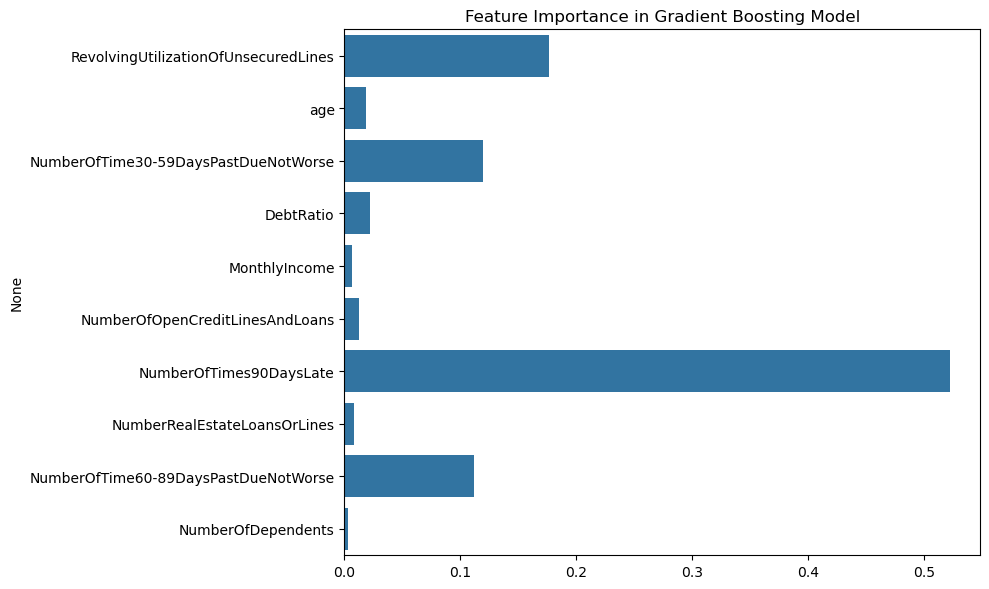

In [13]:
# Step 8: Feature Importance
importances = gbm.feature_importances_
feat_names = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importance in Gradient Boosting Model")
plt.tight_layout()
plt.show()

Feature Importance (What It Means & How to Interpret)

🔹 What it is:
Feature importance tells us how much each feature contributed to improving splits in the decision trees (i.e., reducing error).

📊 How it’s calculated in Gradient Boosting:
Usually based on:
- Frequency of splits using that feature.
- Reduction in loss (log_loss) caused by those splits.

🧠 In the “Give Me Some Credit” dataset, typical important features:
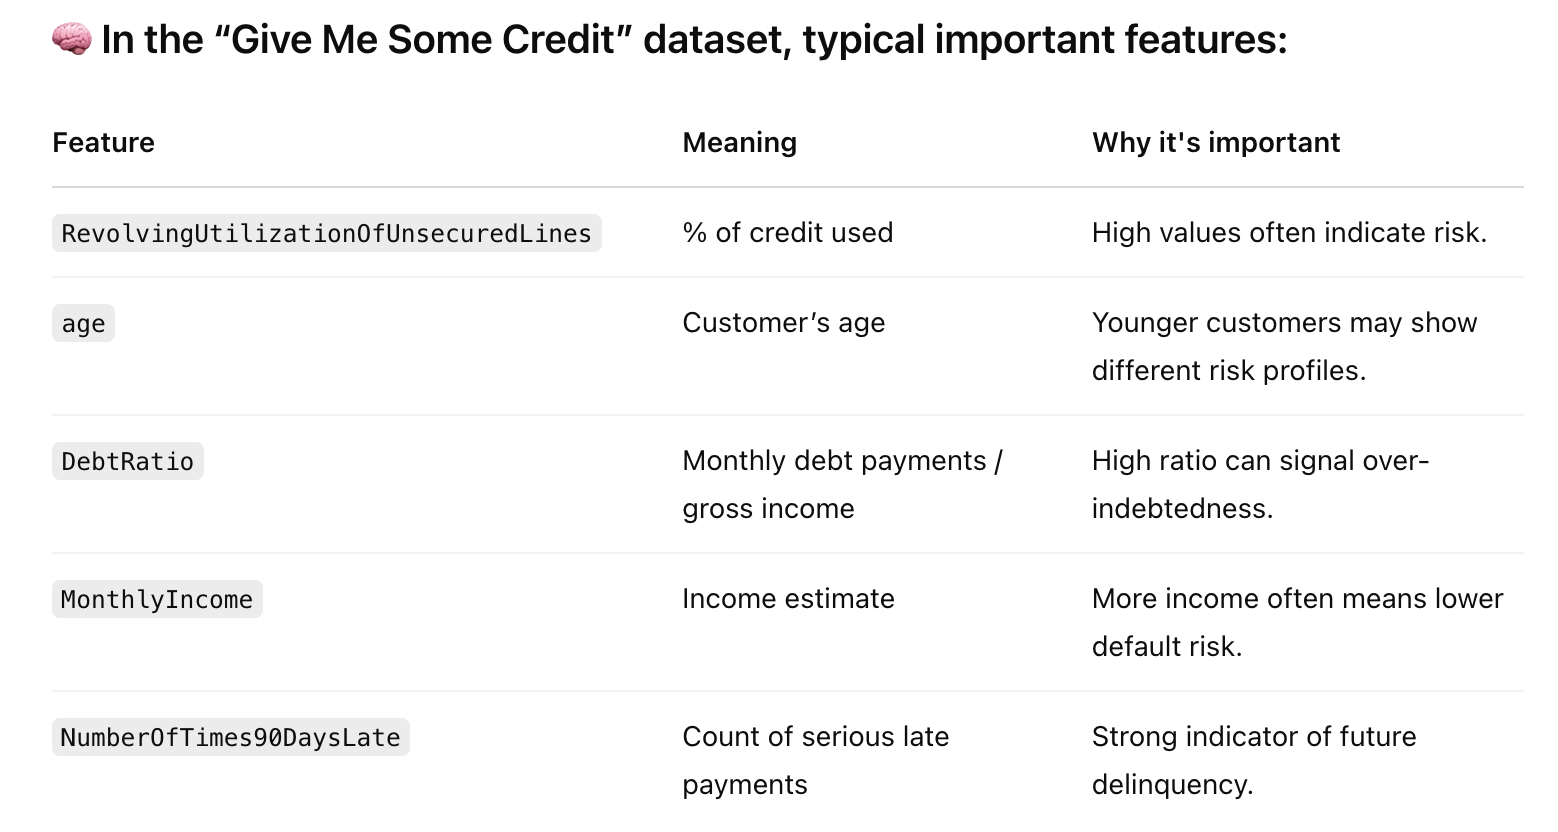

🧠 How to evaluate:

- Top features: Focus on them for insight or feature engineering.
- Low-importance features: Could be dropped to simplify the model or used for further analysis (e.g., multicollinearity).